In [1]:
import torch
from diffusers import DDPMPipeline

W0630 15:12:31.684000 12804 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "C:\Users\ozgur\anaconda3\envs\dl_ortam\lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
ModuleNotFoundError: No module named 'triton'


In [3]:
from datasets import load_dataset

In [4]:
dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

Repo card metadata block was not found. Setting CardData to empty.


In [5]:
from torchvision import transforms

image_size = 64

preprocess = transforms.Compose(
    [
        transforms.Resize((image_size,image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5],[0.5])
    ]
)

In [6]:
def transform(examples):
    examples = [preprocess(image) for image in examples["image"]]
    return {"images": examples}

In [8]:
dataset.set_transform(transform)
batch_size = 16

train_dataloader = torch.utils.data.DataLoader(
    dataset,batch_size=batch_size, shuffle=True
)

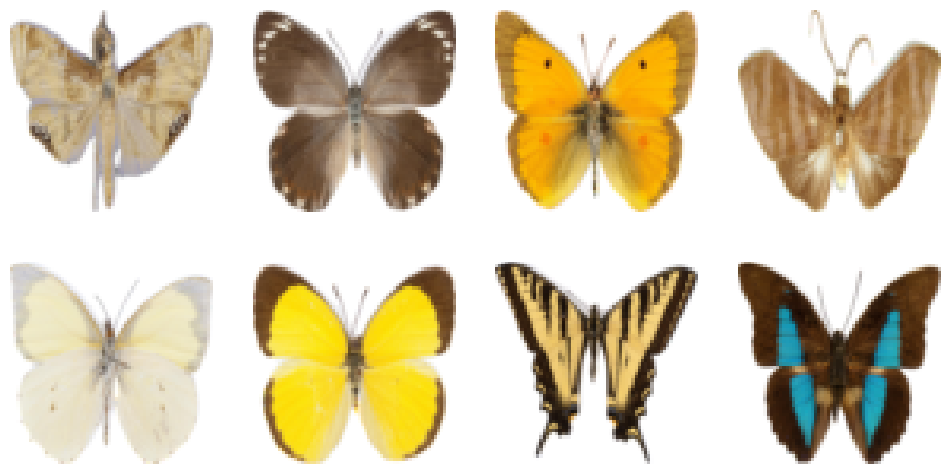

In [10]:
from genaibook.core import show_images
batch = next(iter(train_dataloader))

show_images(batch["images"][:8]*0.5+0.5)

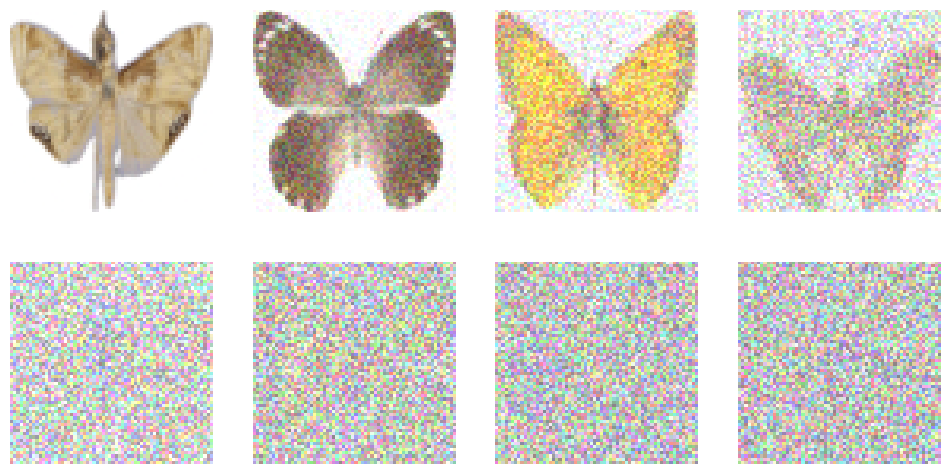

In [13]:
from diffusers import DDPMScheduler

scheduler = DDPMScheduler(
    num_train_timesteps = 1000, beta_start = 0.001, beta_end = 0.02
)

#Create a tensor with 8 evenly spaced values from 0 to 999
timesteps = torch.linspace(0,999,8).long()

#We load 8 images from the dataset and add increasing amounts of noise to them
x = batch["images"][:8]

noise = torch.rand_like(x)
noised_x = scheduler.add_noise(x,noise,timesteps)
show_images((noised_x*0.5+0.5).clip(0,1))

In [14]:
from diffusers import UNet2DModel

In [17]:
from genaibook.core import get_device
device = get_device()

In [18]:
model = UNet2DModel(
    in_channels = 3, #3 channels for RGB images
    sample_size = 64, #Specify out input size
    #The number of channnels per block affects the model size
    block_out_channels = (64,128,256,512),
    down_block_types = (
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D"
    ),
    up_block_types = (
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D"
    )
).to(device)

In [20]:
from torch.nn import functional as F

num_epochs = 50
lr = 1e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
losses = []

#Train the model 
for epoch in range(num_epochs):
    for batch in train_dataloader:
        #Load the input images
        clean_images = batch["images"].to(device)

        #Sample noise to add to the images
        noise = torch.randn(clean_images.shape).to(device)

        #Sample a random timestep for each image
        timesteps = torch.randint(
            0,
            scheduler.config.num_train_timesteps,
            (clean_images.shape[0],),
            device = device
        ).long()

        #Add noise to the clean images according to the noise magnitude at each timestep
        noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

        #Get the model prediction for the noise. The model also uses the timestep as an input fot additional conditioning
        noise_pred = model(noisy_images, timesteps, return_dict = False)[0]

        #Compare the prediction with actual noise
        loss = F.mse_loss(noise_pred, noise)

        #Store the loss for later plotting
        losses.append(loss.item())

        #update the model parameters with the optimizer based on this loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

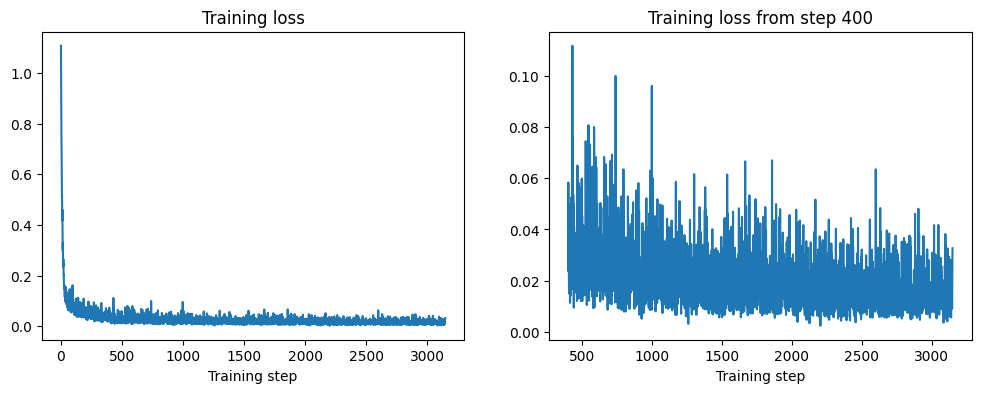

In [21]:
from matplotlib import pyplot as plt
plt.subplots(1, 2, figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Training loss")
plt.xlabel("Training step")
plt.subplot(1, 2, 2)
plt.plot(range(400, len(losses)), losses[400:])
plt.title("Training loss from step 400")
plt.xlabel("Training step");

  0%|          | 0/1000 [00:00<?, ?it/s]

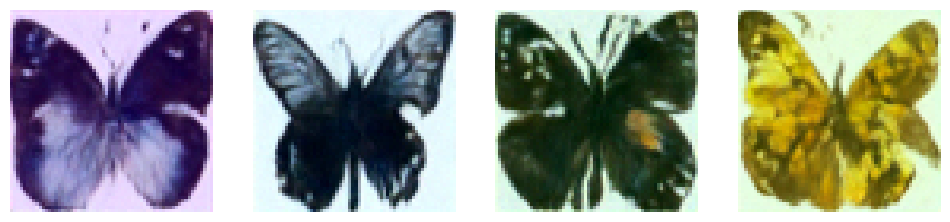

In [22]:
pipeline = DDPMPipeline(unet=model, scheduler=scheduler)
ims = pipeline(batch_size=4).images
show_images(ims, nrows=1)

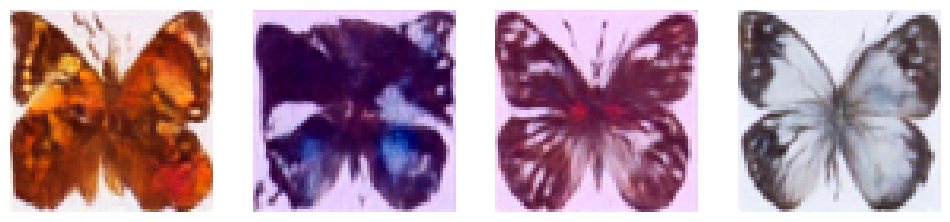

In [25]:
sample = torch.randn(4, 3, 64, 64).to(device)
for t in scheduler.timesteps:
    # Get the model prediction
    with torch.inference_mode():
        noise_pred = model(sample, t)["sample"]
    # Update sample with step
    sample = scheduler.step(noise_pred, t, sample).prev_sample
show_images(sample.clip(-1, 1) * 0.5 + 0.5, nrows=1)